In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
hours_studied = np.arange(1, 21)  # 1 to 20 hours
noise = np.random.normal(loc=0, scale=3, size=hours_studied.shape)
exam_score = hours_studied * 4.5 + noise

df = pd.DataFrame({
    "Hours_Studied": hours_studied,
    "Exam_Score": exam_score
})

print(df.head())
print("Dataset shape:", df.shape)

   Hours_Studied  Exam_Score
0              1    5.990142
1              2    8.585207
2              3   15.443066
3              4   22.569090
4              5   21.797540
Dataset shape: (20, 2)


In [3]:


W1 = np.random.randn(1, 4) * 0.1   # hidden layer weights
b1 = np.zeros((1, 4))              # hidden layer biases

W2 = np.random.randn(4, 1) * 0.1   # output layer weights
b2 = np.zeros((1, 1))              # output layer bias

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (1, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)


In [4]:
def relu(x):
    return np.maximum(0, x)

test_values = np.array([-3, -1, 0, 2, 5])
print("relu test:", relu(test_values))

relu test: [0 0 0 2 5]


In [5]:
def linear(x):
    return x

# The output layer uses linear activation because this is a regression task —
# we want to predict a continuous exam score, and ReLU/Sigmoid would either
# clip negative values or squash the output into a fixed range, which makes
# no sense for a number that can be anything on a continuous scale.

In [6]:
def forward(X, weights, biases):
    W1, W2 = weights["W1"], weights["W2"]
    b1, b2 = biases["b1"], biases["b2"]

    Z1 = X @ W1 + b1          # weighted sum, hidden layer
    A1 = relu(Z1)              # ReLU activation

    Z2 = A1 @ W2 + b2          # weighted sum, output layer
    A2 = linear(Z2)            # linear activation

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2}
    return A2, cache

weights = {"W1": W1, "W2": W2}
biases = {"b1": b1, "b2": b2}

X_sample = df["Hours_Studied"].values[:4].reshape(-1, 1)
preds_sample, _ = forward(X_sample, weights, biases)
print("Predicted scores (untrained network):")
print(preds_sample)

Predicted scores (untrained network):
[[-0.00875598]
 [-0.01751197]
 [-0.02626795]
 [-0.03502394]]


In [7]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

y_sample = df["Exam_Score"].values[:4].reshape(-1, 1)
loss_sample = mse_loss(y_sample, preds_sample)
print("MSE loss on first 4 rows:", loss_sample)

MSE loss on first 4 rows: 215.05994654365162


In [8]:
def relu_derivative(x):
    return (x > 0).astype(float)

def backward(X, y_true, y_pred, cache, weights):
    n = X.shape[0]
    Z1, A1 = cache["Z1"], cache["A1"]
    W2 = weights["W2"]

    # output layer (linear activation, so dA2/dZ2 = 1)
    dZ2 = -2 * (y_true - y_pred) / n         # (n, 1)
    dW2 = A1.T @ dZ2                          # (4, 1)
    db2 = np.sum(dZ2, axis=0, keepdims=True)  # (1, 1)

    # hidden layer
    dA1 = dZ2 @ W2.T                          # (n, 4)
    dZ1 = dA1 * relu_derivative(Z1)           # (n, 4)
    dW1 = X.T @ dZ1                           # (1, 4)
    db1 = np.sum(dZ1, axis=0, keepdims=True)  # (1, 4)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

grads_sample = backward(X_sample, y_sample, preds_sample, _, weights)

print("dW1 shape:", grads_sample["dW1"].shape, "-> matches W1", W1.shape)
print("db1 shape:", grads_sample["db1"].shape, "-> matches b1", b1.shape)
print("dW2 shape:", grads_sample["dW2"].shape, "-> matches W2", W2.shape)
print("db2 shape:", grads_sample["db2"].shape, "-> matches b2", b2.shape)

dW1 shape: (1, 4) -> matches W1 (1, 4)
db1 shape: (1, 4) -> matches b1 (1, 4)
dW2 shape: (4, 1) -> matches W2 (4, 1)
db2 shape: (1, 1) -> matches b2 (1, 1)


In [9]:
def update_params(weights, biases, grads, learning_rate):
    weights["W1"] = weights["W1"] - learning_rate * grads["dW1"]
    weights["W2"] = weights["W2"] - learning_rate * grads["dW2"]
    biases["b1"] = biases["b1"] - learning_rate * grads["db1"]
    biases["b2"] = biases["b2"] - learning_rate * grads["db2"]
    return weights, biases

learning_rate = 0.001
weights, biases = update_params(weights, biases, grads_sample, learning_rate)
print("Weights and biases updated with one gradient step.")

Weights and biases updated with one gradient step.


In [10]:
def make_batches(X, y, batch_size=4):
    n = X.shape[0]
    batches = []
    for start in range(0, n, batch_size):
        end = start + batch_size
        batches.append((X[start:end], y[start:end]))
    return batches

# Hours_Studied ranges up to 20, which makes the gradients w.r.t. W1 quite large
# (dW1 = X.T @ dZ1) and pushes gradient descent into instability. Scaling the
# input down to a 0-1 range keeps the gradients well-behaved without changing
# the architecture or what the network learns.
X_all = (df["Hours_Studied"].values / 20.0).reshape(-1, 1)
y_all = df["Exam_Score"].values.reshape(-1, 1).astype(float)

batches = make_batches(X_all, y_all, batch_size=4)
print("Number of batches:", len(batches))

Number of batches: 5


In [11]:
# reset weights and biases so we train from scratch, cleanly
np.random.seed(42)
weights = {
    "W1": np.random.randn(1, 4) * 0.1,
    "W2": np.random.randn(4, 1) * 0.1,
}
biases = {
    "b1": np.zeros((1, 4)),
    "b2": np.zeros((1, 1)),
}

learning_rate = 0.001
epochs = 100
loss_history = []

for epoch in range(1, epochs + 1):
    batches = make_batches(X_all, y_all, batch_size=4)
    epoch_losses = []

    for X_batch, y_batch in batches:
        y_pred, cache = forward(X_batch, weights, biases)
        loss = mse_loss(y_batch, y_pred)
        epoch_losses.append(loss)

        grads = backward(X_batch, y_batch, y_pred, cache, weights)
        weights, biases = update_params(weights, biases, grads, learning_rate)

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | avg loss: {avg_loss:.4f}")

Epoch   1 | avg loss: 2757.4289
Epoch  10 | avg loss: 334.8932
Epoch  20 | avg loss: 182.9147
Epoch  30 | avg loss: 72.4941
Epoch  40 | avg loss: 22.5949
Epoch  50 | avg loss: 8.3497
Epoch  60 | avg loss: 5.5816
Epoch  70 | avg loss: 5.1734
Epoch  80 | avg loss: 5.1315
Epoch  90 | avg loss: 5.1330
Epoch 100 | avg loss: 5.1361


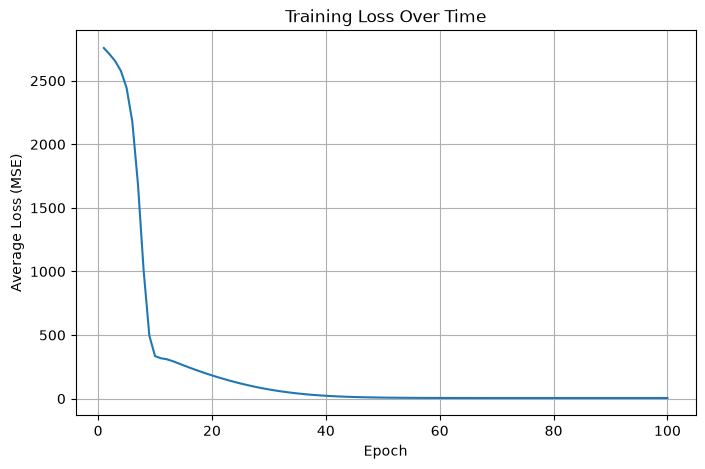

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Loss (MSE)")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

In [13]:
test_hours = np.array([[3], [11], [18]], dtype=float)
test_hours_scaled = test_hours / 20.0  # same scaling used during training
test_preds, _ = forward(test_hours_scaled, weights, biases)

for h, p in zip(test_hours.flatten(), test_preds.flatten()):
    print(f"Hours studied: {h:.0f} -> Predicted exam score: {p:.2f}")

# Rough sanity check: with Exam_Score ~= 4.5 * Hours_Studied, we'd expect
# roughly 13.5, 49.5 and 81 for 3, 11 and 18 hours. If the printed predictions
# land in that ballpark, the network has learned the underlying trend well.

Hours studied: 3 -> Predicted exam score: 15.12
Hours studied: 11 -> Predicted exam score: 48.85
Hours studied: 18 -> Predicted exam score: 78.36


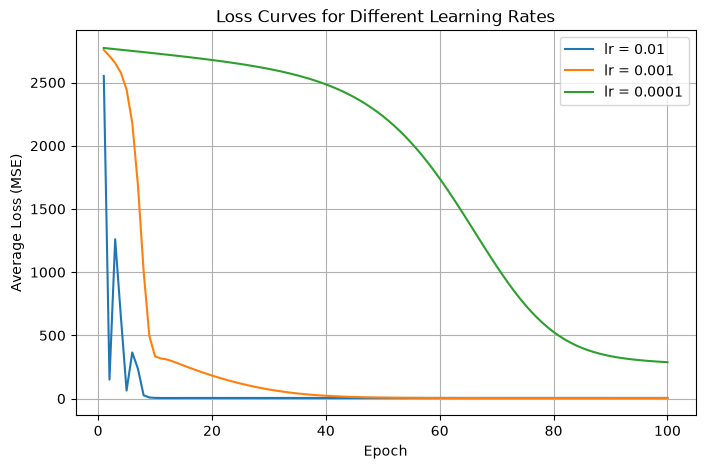

Learning rate 0.01: final loss = 5.3320
Learning rate 0.001: final loss = 5.1361
Learning rate 0.0001: final loss = 288.1958


In [14]:
def train_network(X_all, y_all, learning_rate, epochs=100, batch_size=4, seed=42):
    np.random.seed(seed)
    weights = {
        "W1": np.random.randn(1, 4) * 0.1,
        "W2": np.random.randn(4, 1) * 0.1,
    }
    biases = {
        "b1": np.zeros((1, 4)),
        "b2": np.zeros((1, 1)),
    }

    history = []
    for epoch in range(epochs):
        epoch_losses = []
        for X_batch, y_batch in make_batches(X_all, y_all, batch_size):
            y_pred, cache = forward(X_batch, weights, biases)
            epoch_losses.append(mse_loss(y_batch, y_pred))
            grads = backward(X_batch, y_batch, y_pred, cache, weights)
            weights, biases = update_params(weights, biases, grads, learning_rate)
        history.append(np.mean(epoch_losses))

    return history

learning_rates = [0.01, 0.001, 0.0001]
histories = {lr: train_network(X_all, y_all, lr) for lr in learning_rates}

plt.figure(figsize=(8, 5))
for lr, history in histories.items():
    plt.plot(range(1, len(history) + 1), history, label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Average Loss (MSE)")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

for lr, history in histories.items():
    print(f"Learning rate {lr}: final loss = {history[-1]:.4f}")